# Config


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import os
from dotenv import load_dotenv

from entsoe import EntsoePandasClient

load_dotenv()

# ENTSOE Token
entsoe_token = os.getenv("ENTSOE_API_TOKEN")

# ENTSOE Client
entsoe_client = EntsoePandasClient(api_key=entsoe_token)

# Fetch Day-Ahead Prices

In [2]:
# Location
country_capital = "Madrid"
country_code = "ES"


# Period
today = pd.Timestamp.now(
    tz=f"Europe/{country_capital}"
).normalize()

yesterday=(pd.Timestamp.now(tz=f"Europe/{country_capital}")
    .normalize()
    - pd.Timedelta(days=1)
)
last_week=(pd.Timestamp.now(tz=f"Europe/{country_capital}")
    .normalize()
    - pd.Timedelta(days=7)
)


start=last_week
end=today

In [3]:
df = entsoe_client.query_day_ahead_prices(
    country_code=country_code,
    start=last_week,
    end=today)

df.info()

<class 'pandas.Series'>
DatetimeIndex: 673 entries, 2026-08-08 00:00:00+02:00 to 2026-08-15 00:00:00+02:00
Series name: None
Non-Null Count  Dtype  
--------------  -----  
673 non-null    float64
dtypes: float64(1)
memory usage: 10.5 KB


In [4]:
df.head()

2026-08-08 00:00:00+02:00    182.68
2026-08-08 00:15:00+02:00    181.77
2026-08-08 00:30:00+02:00    181.27
2026-08-08 00:45:00+02:00    179.27
2026-08-08 01:00:00+02:00    178.22
dtype: float64

In [5]:
df.tail()

2026-08-14 23:00:00+02:00    186.06
2026-08-14 23:15:00+02:00    182.02
2026-08-14 23:30:00+02:00    175.00
2026-08-14 23:45:00+02:00    166.99
2026-08-15 00:00:00+02:00    186.49
dtype: float64

In [6]:
# Check that timestamps are unique
assert df.index.is_unique

# Check that timestamps are sorted
assert df.index.is_monotonic_increasing

In [7]:
df = df.reset_index(name="da_price").rename(columns={"index": "date"})
df

,date,da_price
0,2026-08-08 00:00:00+02:00,182.68
1,2026-08-08 00:15:00+02:00,181.77
2,2026-08-08 00:30:00+02:00,181.27
3,2026-08-08 00:45:00+02:00,179.27
4,2026-08-08 01:00:00+02:00,178.22
...,...,...
668,2026-08-14 23:00:00+02:00,186.06
669,2026-08-14 23:15:00+02:00,182.02
670,2026-08-14 23:30:00+02:00,175.00
671,2026-08-14 23:45:00+02:00,166.99


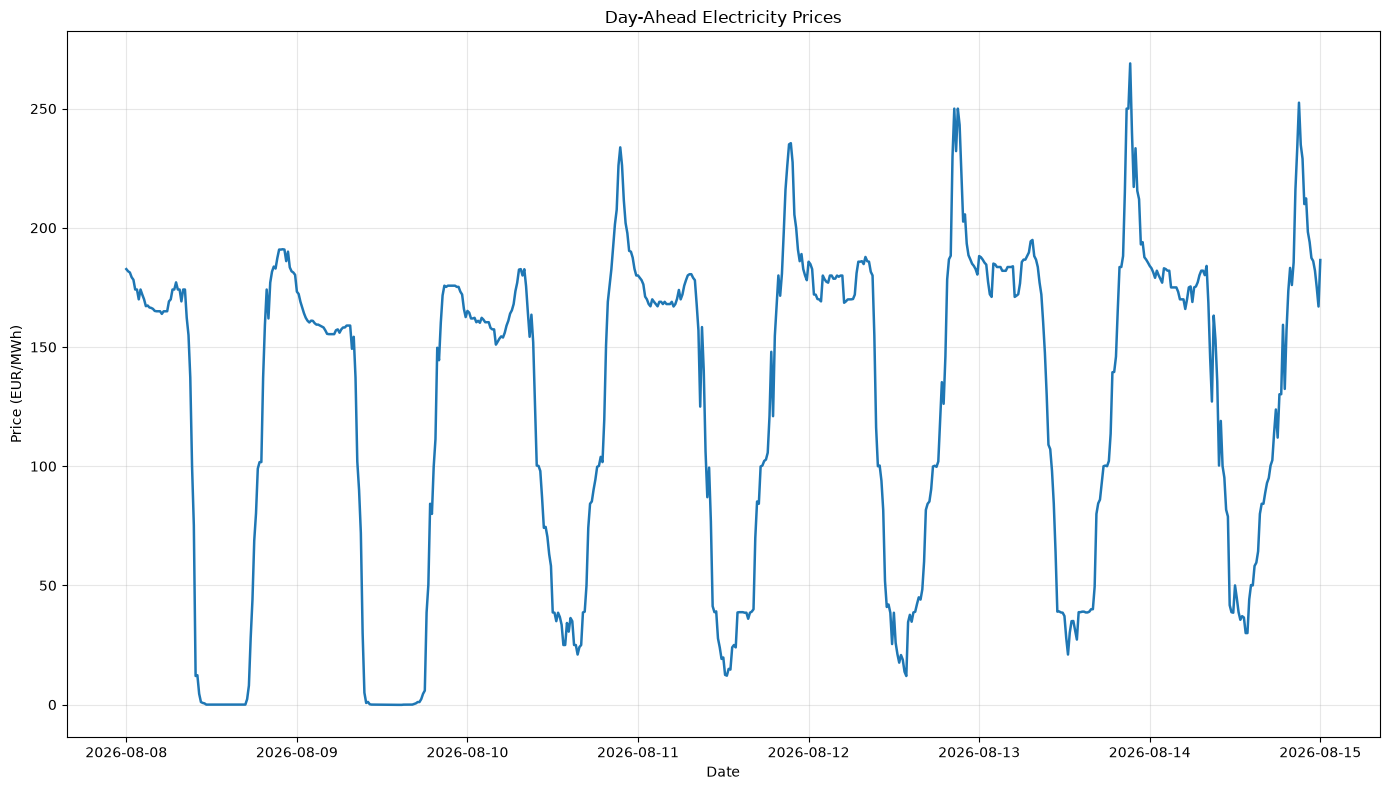

In [8]:
# Plot \Day-Ahead Electricity Prices/

plt.figure(figsize=(14, 8))

plt.plot(
    df["date"],
    df["da_price"],
    linewidth=1.8
)

plt.title("Day-Ahead Electricity Prices")
plt.xlabel("Date")
plt.ylabel("Price (EUR/MWh)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
da_prices = df["da_price"]

average_price = da_prices.mean()
peak_price = da_prices.max()
lowest_price = da_prices.min()
price_spread = peak_price - lowest_price

hourly_change = da_prices.diff()

largest_hourly_increase = hourly_change.max()
largest_hourly_decrease = hourly_change.min()

price_volatility = da_prices.std()

negative_price_hours = (da_prices < 0).sum()
negative_price_percentage = (da_prices < 0).mean() * 100

In [10]:
print("=" * 70)
print("ENTSO-E DAY-AHEAD ELECTRICITY PRICE ANALYSIS")
print("=" * 70)

print(f"Analysis date : {today}")
print(f"Zone          : {country_code}")
print()

summary = pd.Series({
    "Average price": average_price,
    "Peak price": peak_price,
    "Lowest price": lowest_price,
    "Price spread": price_spread,
    "Largest hourly increase": largest_hourly_increase,
    "Largest hourly decrease": largest_hourly_decrease,
    "Price volatility": price_volatility,
    "Negative-price hours": negative_price_hours,
    "Negative-price %": negative_price_percentage
}).round(2)

print(summary)

ENTSO-E DAY-AHEAD ELECTRICITY PRICE ANALYSIS
Analysis date : 2026-08-15 00:00:00+02:00
Zone          : ES

Average price              124.79
Peak price                 268.97
Lowest price                -0.11
Price spread               269.08
Largest hourly increase     41.61
Largest hourly decrease    -63.15
Price volatility            69.97
Negative-price hours        18.00
Negative-price %             2.67
dtype: float64
